# **SuperKart Sales Forecasting and Deployment**

## **Business Context**
Accurate product-store sales forecasts support inventory procurement, territory planning, regional strategy, and performance benchmarking. SuperKart wants a reusable forecasting service that can estimate sales revenue consistently across its network.

## **Objective**
Develop, tune, evaluate, serialize, and deploy a supervised regression model that predicts `Product_Store_Sales_Total` from product and store characteristics. The solution includes a Flask prediction API, a Streamlit interface, Docker containers, and both single and batch inference.

## **Scope Note**
The data has no transaction date or ordered sales history. Therefore, this project is a **cross-sectional product-store revenue prediction** problem rather than a classical time-series forecast. Predictions can be aggregated by outlet or region to support quarterly planning, but seasonality and trend cannot be estimated from this dataset.

## **Data Dictionary**
The source data contains product identifiers, weight, sugar content, display allocation, product category, MRP, store identifiers, establishment year, size, city tier, store type, and the target sales revenue.

# **Imports and Configuration**

In [1]:
# In a clean Colab runtime, install the pinned versions before importing:
# %pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 flask==3.1.2 requests==2.32.4 -q

In [2]:
import io
import json
import os
import platform
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}, pandas: {pd.__version__}, scikit-learn: {sklearn.__version__}")

Python: 3.11.12
NumPy: 2.0.2, pandas: 2.2.2, scikit-learn: 1.6.1


# **Loading the Dataset**

In [3]:
DATA_PATH = Path("SuperKart.csv")
BATCH_PATH = Path("Batch_Data_SuperKart.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Place SuperKart.csv in the notebook working directory.")

data = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
display(data.head())

Dataset shape: 8,763 rows x 12 columns


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.6600,Low Sugar,0.0270,Frozen Foods,117.0800,OUT004,2009,Medium,Tier 2,Supermarket Type2,"2,842.4000"
1,FD7839,16.5400,Low Sugar,0.1440,Dairy,171.4300,OUT003,1999,Medium,Tier 1,Departmental Store,"4,830.0200"
2,FD5075,14.2800,Regular,0.0310,Canned,162.0800,OUT001,1987,High,Tier 2,Supermarket Type1,"4,130.1600"
3,FD8233,12.1000,Low Sugar,0.1120,Baking Goods,186.3100,OUT001,1987,High,Tier 2,Supermarket Type1,"4,132.1800"
4,NC1180,9.5700,No Sugar,0.0100,Health and Hygiene,123.6700,OUT002,1998,Small,Tier 3,Food Mart,"2,279.3600"


# **Data Overview**

In [4]:
overview = pd.DataFrame({
    "Data Type": data.dtypes.astype(str),
    "Missing Values": data.isna().sum(),
    "Unique Values": data.nunique(),
})
display(overview)
print(f"Exact duplicate rows: {data.duplicated().sum():,}")
display(data.describe(include="all").T)

,Data Type,Missing Values,Unique Values
Product_Id,object,0,8763
Product_Weight,float64,0,1113
Product_Sugar_Content,object,0,4
Product_Allocated_Area,float64,0,228
Product_Type,object,0,16
Product_MRP,float64,0,6100
Store_Id,object,0,4
Store_Establishment_Year,int64,0,4
Store_Size,object,0,3
Store_Location_City_Type,object,0,3


Exact duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,"8,763.0000",NaN,NaN,NaN,12.6538,2.2173,4.0000,11.1500,12.6600,14.1800,22.0000
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,"8,763.0000",NaN,NaN,NaN,0.0688,0.0482,0.0040,0.0310,0.0560,0.0960,0.2980
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,"8,763.0000",NaN,NaN,NaN,147.0325,30.6941,31.0000,126.1600,146.7400,167.5850,266.0000
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,"8,763.0000",NaN,NaN,NaN,"2,002.0328",8.3884,"1,987.0000","1,998.0000","2,009.0000","2,009.0000","2,009.0000"
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Data Overview Observations**
- The dataset has **8,763 observations and 12 variables**, with seven categorical and five numeric columns including the target.
- There are **no missing values and no exact duplicate rows**, so no imputation or duplicate removal is required.
- `Product_Id` is unique for every row and would encourage memorization if one-hot encoded. Only its two-letter product-family prefix is retained.
- `Store_Id` has four values and is redundant with the supplied store attributes. It is excluded to keep the model contract interpretable and compatible with the batch data.
- `Product_Sugar_Content` contains `reg`, an inconsistent spelling that is standardized to `Regular`.

# **Exploratory Data Analysis**
## **Univariate Analysis**

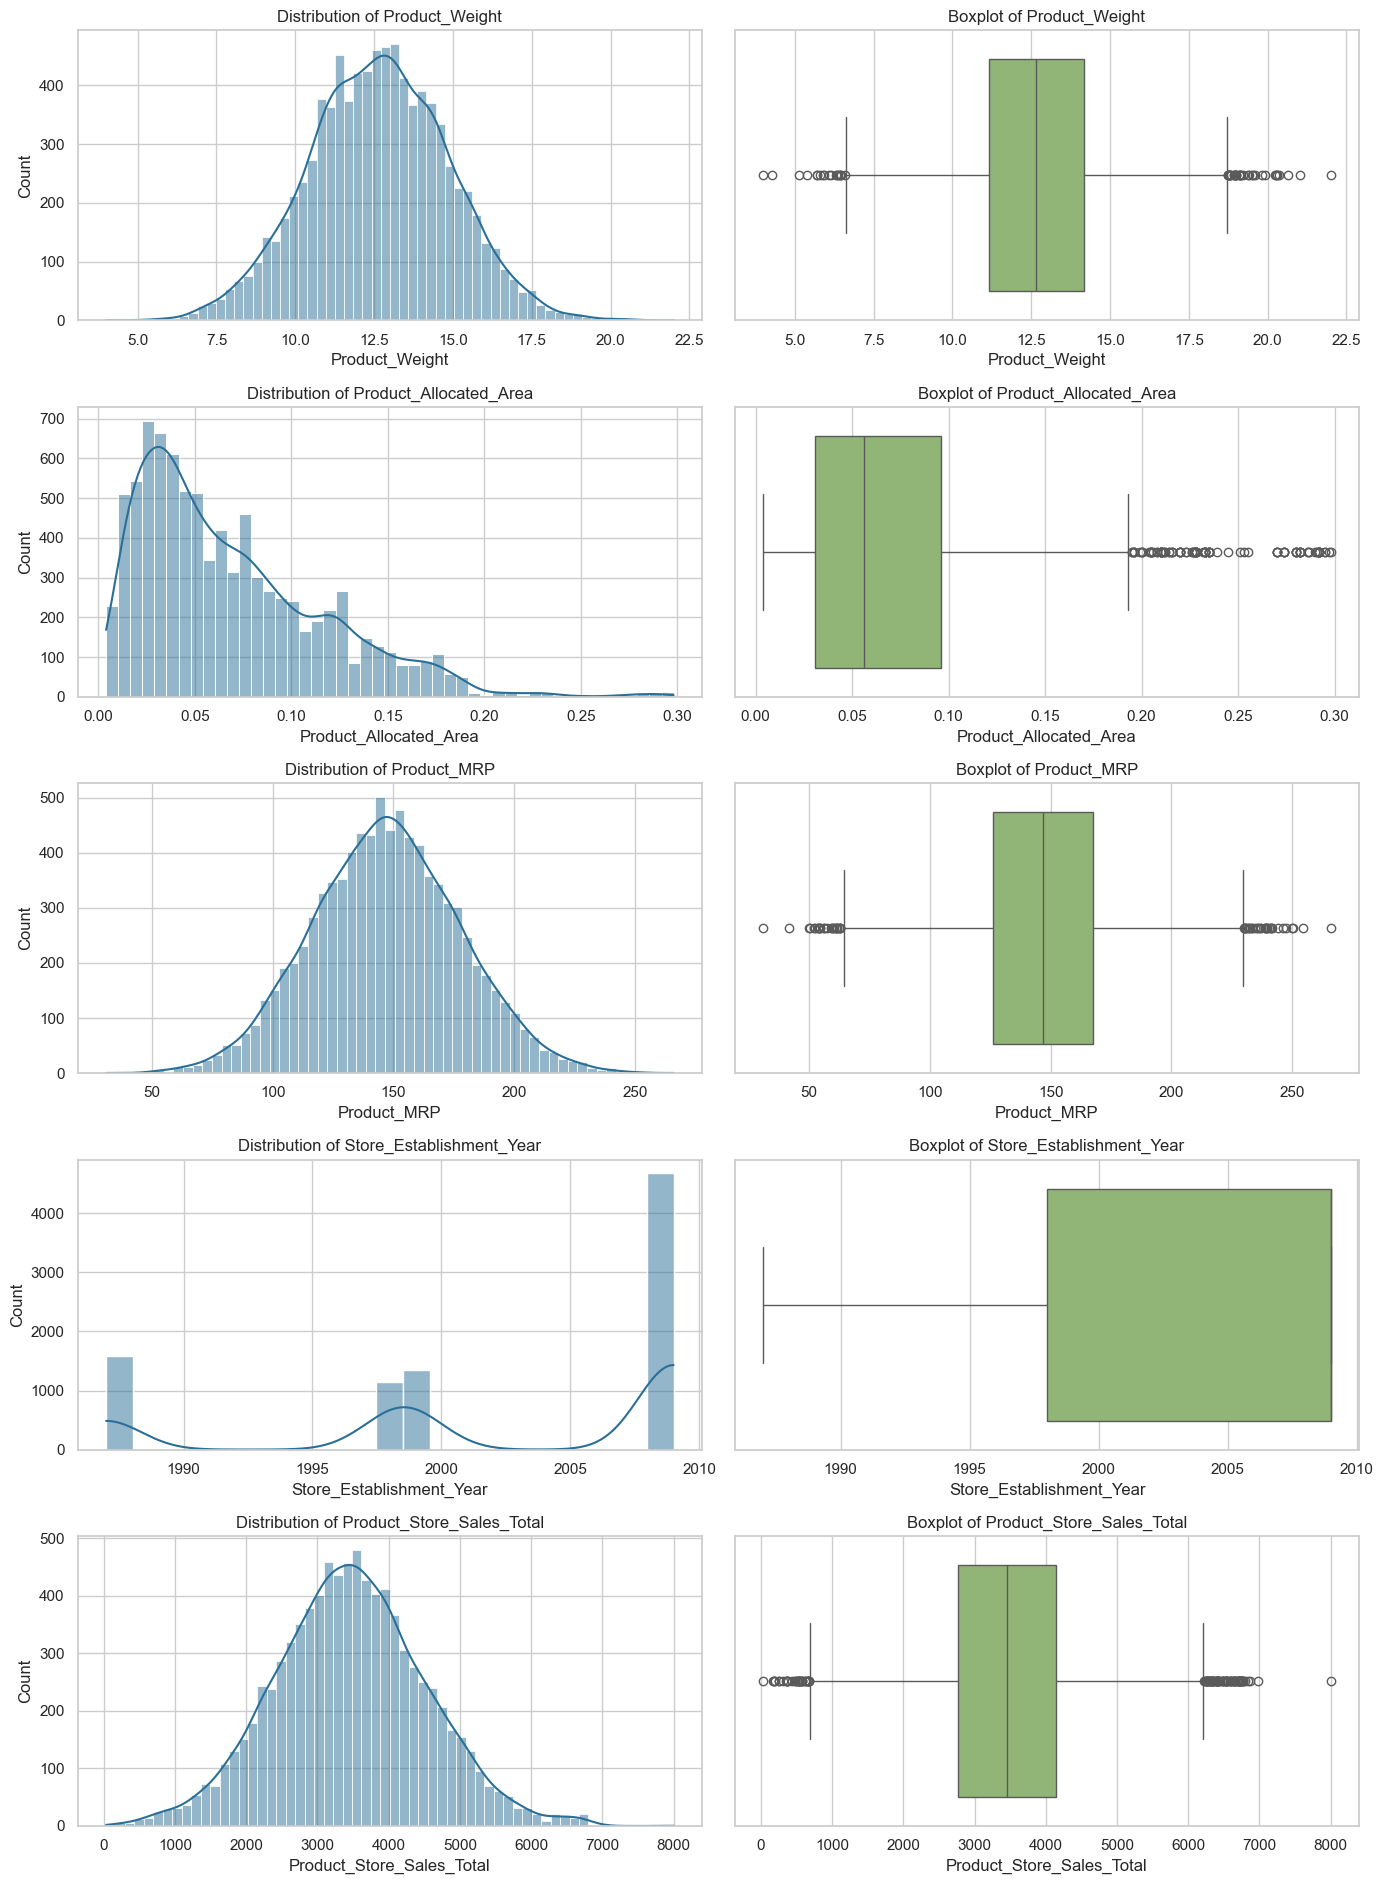

In [5]:
numeric_columns = [
    "Product_Weight", "Product_Allocated_Area", "Product_MRP",
    "Store_Establishment_Year", "Product_Store_Sales_Total"
]
fig, axes = plt.subplots(len(numeric_columns), 2, figsize=(14, 19))
for row, column in enumerate(numeric_columns):
    sns.histplot(data=data, x=column, kde=True, ax=axes[row, 0], color="#2a6f97")
    sns.boxplot(data=data, x=column, ax=axes[row, 1], color="#90be6d")
    axes[row, 0].set_title(f"Distribution of {column}")
    axes[row, 1].set_title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

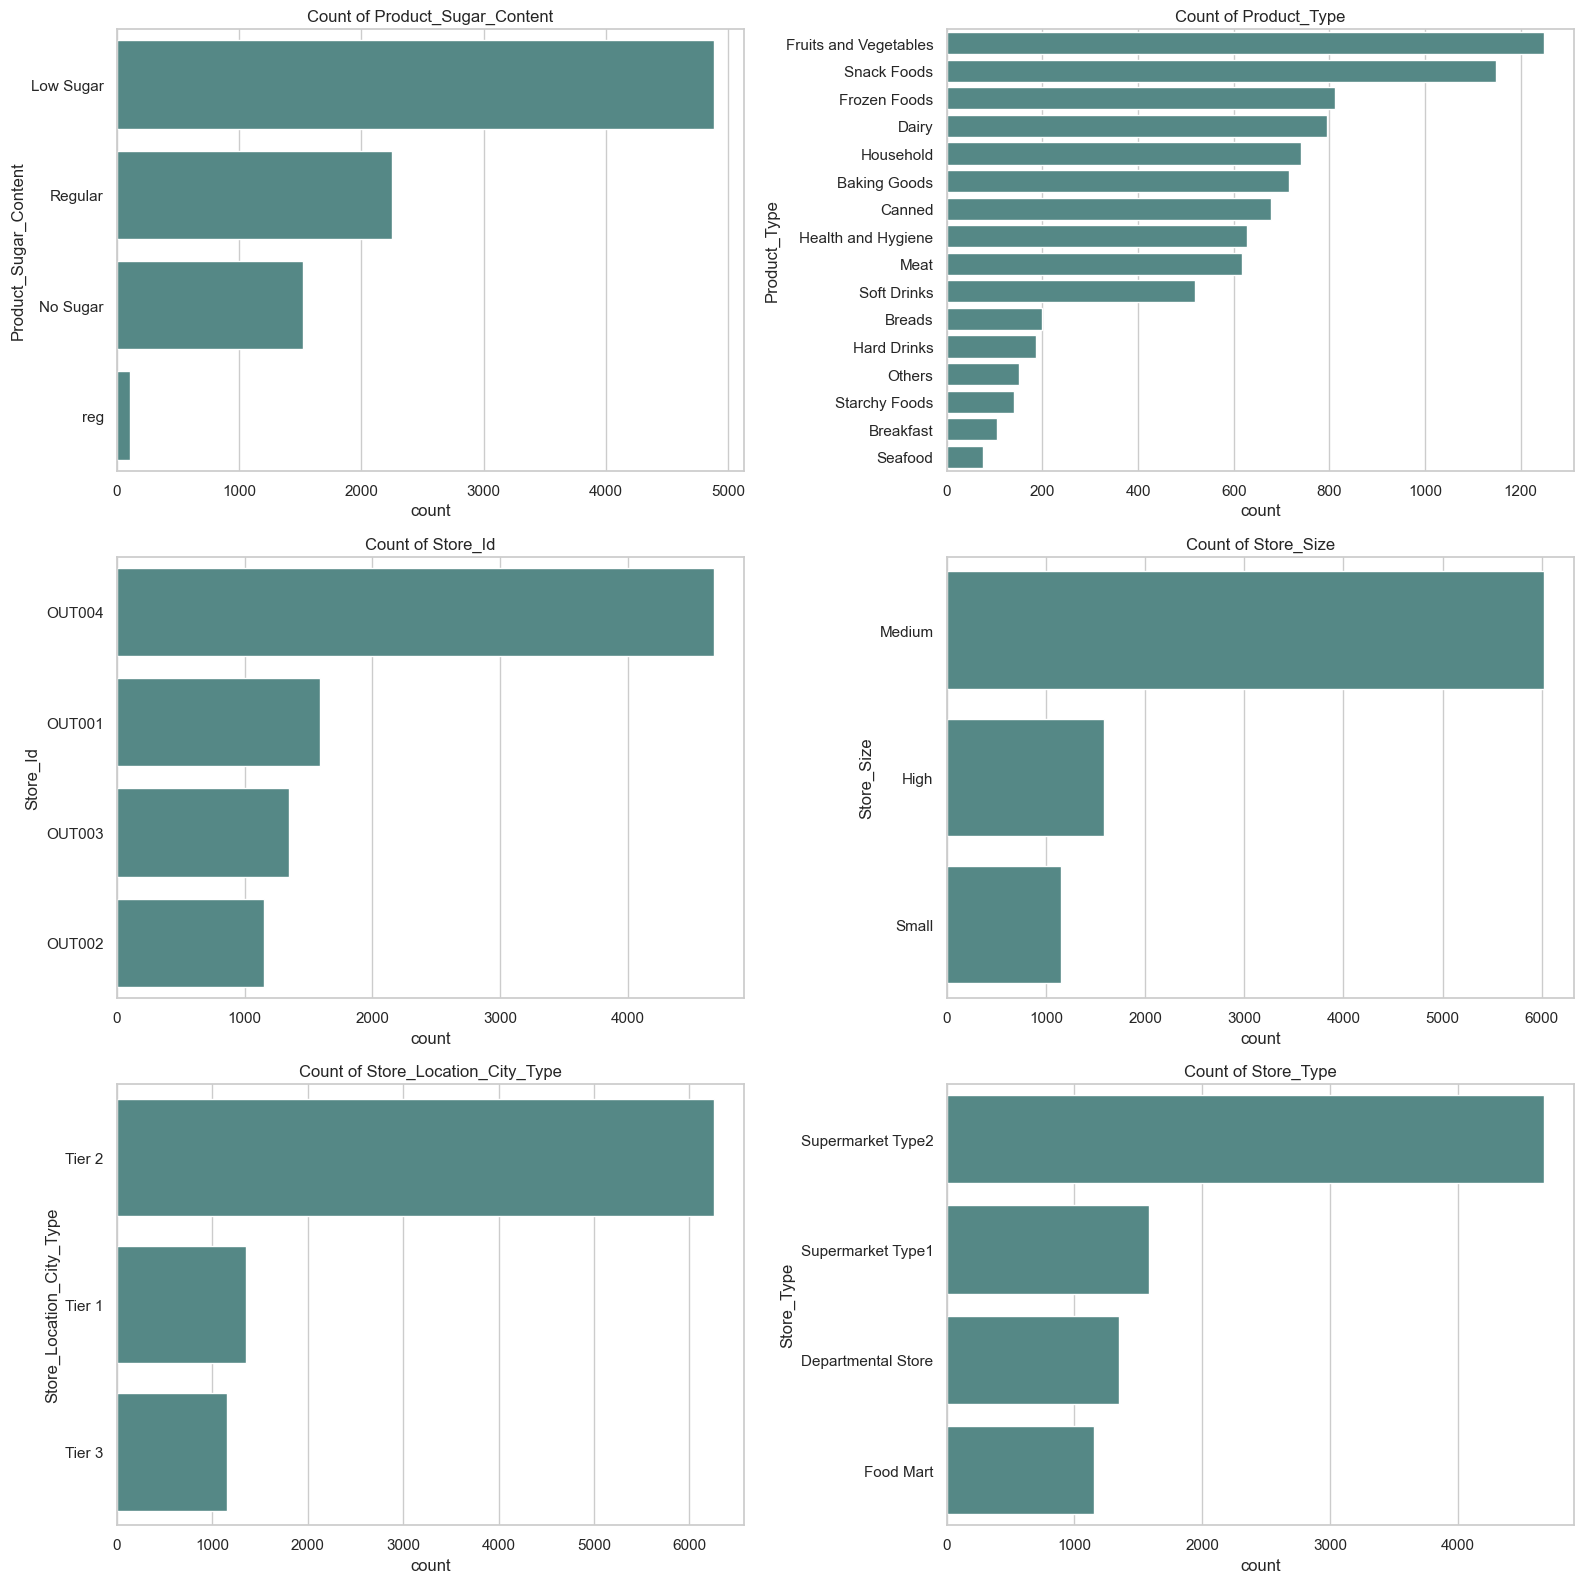

In [6]:
categorical_columns_raw = [
    "Product_Sugar_Content", "Product_Type", "Store_Id",
    "Store_Size", "Store_Location_City_Type", "Store_Type"
]
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
for axis, column in zip(axes.flat, categorical_columns_raw):
    order = data[column].value_counts().index
    sns.countplot(data=data, y=column, order=order, ax=axis, color="#4d908e")
    axis.set_title(f"Count of {column}")
plt.tight_layout()
plt.show()

In [7]:
outlier_rows = []
for column in numeric_columns:
    q1, q3 = data[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((data[column] < lower) | (data[column] > upper)).sum()
    outlier_rows.append({
        "Variable": column, "Lower Fence": lower, "Upper Fence": upper,
        "Outlier Count": count, "Outlier Percentage": 100 * count / len(data),
    })
outlier_summary = pd.DataFrame(outlier_rows).set_index("Variable")
display(outlier_summary)

,Lower Fence,Upper Fence,Outlier Count,Outlier Percentage
Variable,,,,
Product_Weight,6.6050,18.7250,54,0.6162
Product_Allocated_Area,-0.0665,0.1935,104,1.1868
Product_MRP,64.0225,229.7225,57,0.6505
Store_Establishment_Year,"1,981.5000","2,025.5000",0,0.0000
Product_Store_Sales_Total,686.5400,"6,220.3400",119,1.3580


### **Univariate Observations and Outlier Decision**
- Sales are centered near 3,464, with a median near 3,452 and a broad but approximately symmetric distribution.
- Product allocated area is right-skewed, while product weight and MRP are comparatively symmetric.
- IQR flags affect only small proportions of the numeric fields. Values such as high MRP, weight, allocation, and sales remain plausible business observations rather than clear data errors.
- **No outlier treatment is applied.** Deleting or capping valid high-value products could suppress strategically important demand, while tree ensembles are robust to extreme predictor values.

## **Bivariate Analysis**

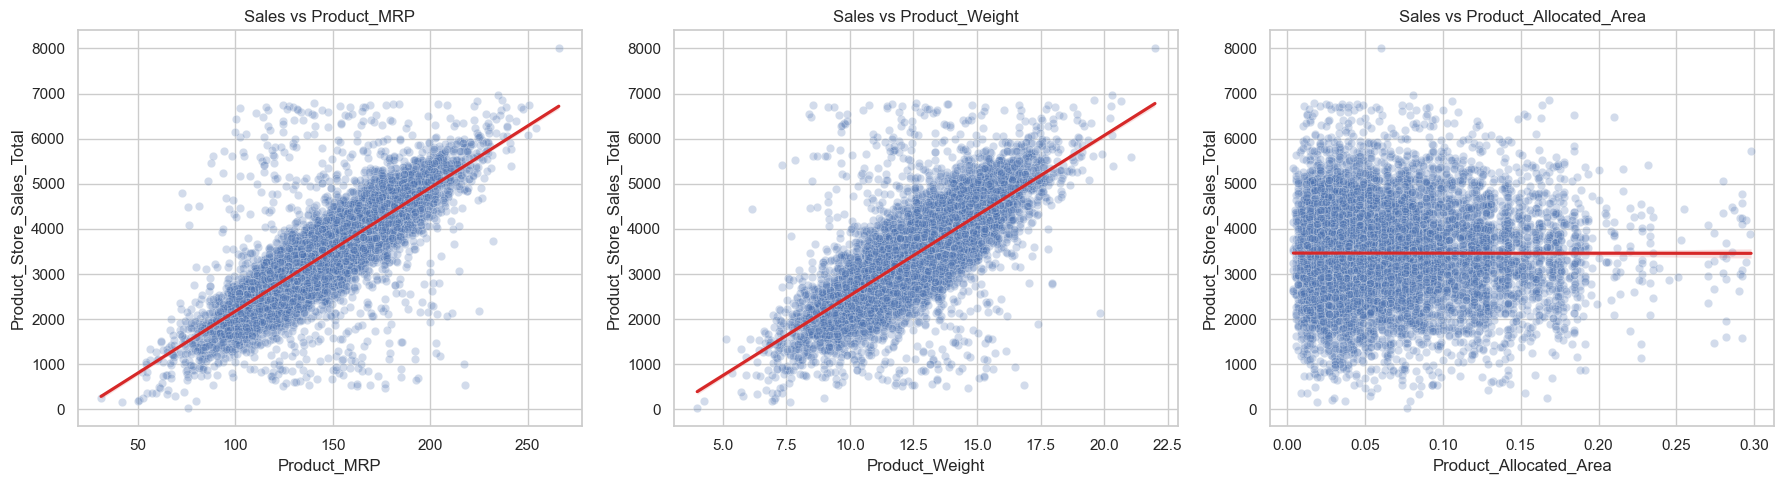

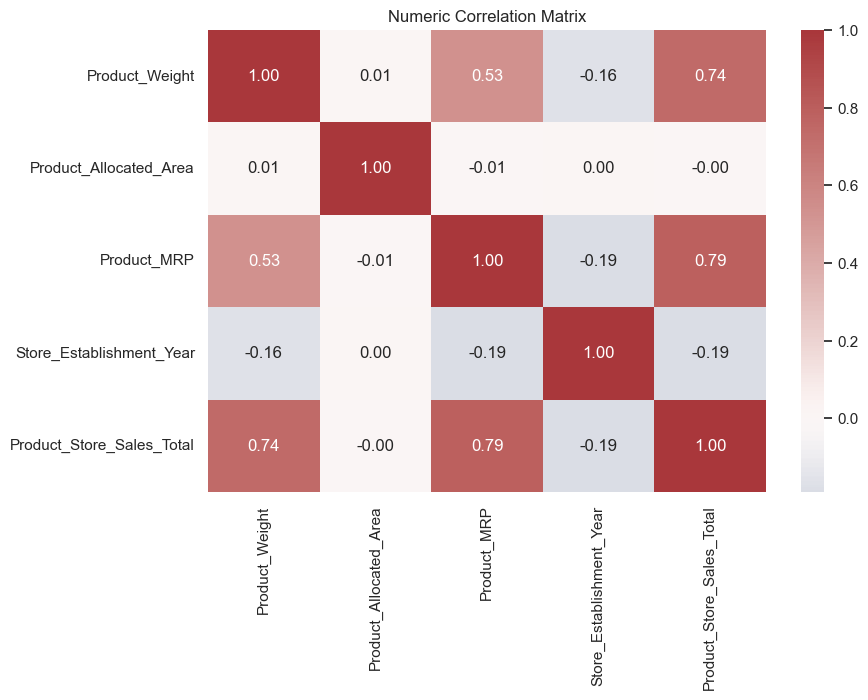

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for axis, column in zip(axes, ["Product_MRP", "Product_Weight", "Product_Allocated_Area"]):
    sns.scatterplot(data=data, x=column, y="Product_Store_Sales_Total", alpha=0.25, ax=axis)
    sns.regplot(data=data, x=column, y="Product_Store_Sales_Total", scatter=False, color="#d62828", ax=axis)
    axis.set_title(f"Sales vs {column}")
plt.tight_layout()
plt.show()

correlations = data[numeric_columns].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Numeric Correlation Matrix")
plt.show()

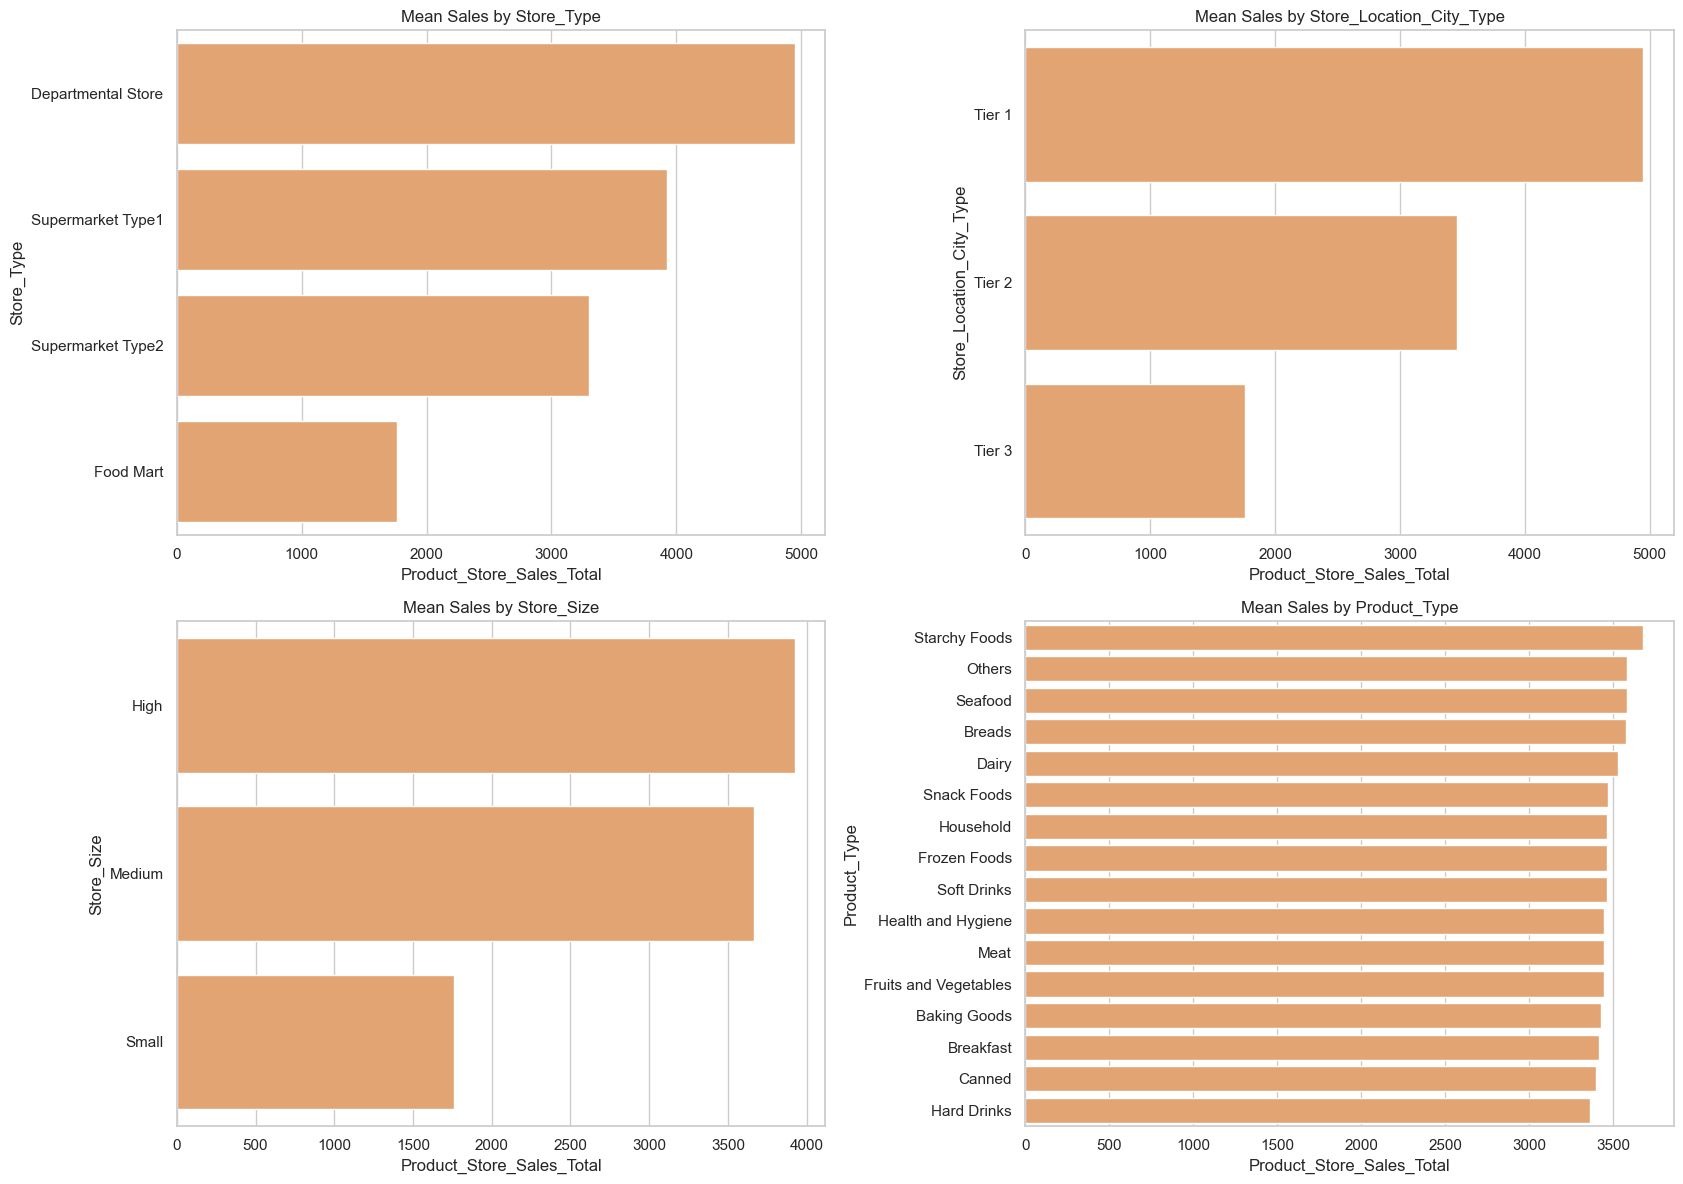

,,,count,mean,median
Store_Type,Store_Location_City_Type,Store_Size,,,
Departmental Store,Tier 1,Medium,1349,"4,946.9663","4,958.2900"
Supermarket Type1,Tier 2,High,1586,"3,923.7788","4,139.6450"
Supermarket Type2,Tier 2,Medium,4676,"3,299.3121","3,304.1800"
Food Mart,Tier 3,Small,1152,"1,762.9425","1,889.4950"


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
for axis, column in zip(axes.flat, ["Store_Type", "Store_Location_City_Type", "Store_Size", "Product_Type"]):
    order = data.groupby(column)["Product_Store_Sales_Total"].mean().sort_values(ascending=False).index
    sns.barplot(data=data, y=column, x="Product_Store_Sales_Total", order=order, errorbar=None, ax=axis, color="#f4a261")
    axis.set_title(f"Mean Sales by {column}")
plt.tight_layout()
plt.show()

store_summary = data.groupby(["Store_Type", "Store_Location_City_Type", "Store_Size"], observed=True)["Product_Store_Sales_Total"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
display(store_summary)

### **Bivariate Insights**
- `Product_MRP` has the strongest numeric relationship with sales (correlation about 0.79), followed by product weight (about 0.74). Allocated display area has almost no linear association in this dataset.
- Departmental stores and Tier 1 locations have the highest average product-store sales, while Food Marts and Tier 3 locations have the lowest.
- Store ID, type, city tier, size, and age are strongly confounded because the data contains only four stores. Their associations are predictive but should not be interpreted as independent causal effects.
- Product categories have much smaller average-sales differences than MRP, weight, and store characteristics.

# **Data Preprocessing and Feature Engineering**

In [10]:
REFERENCE_YEAR = 2025
PERISHABLE_TYPES = {
    "Dairy", "Meat", "Fruits and Vegetables", "Breakfast",
    "Breads", "Seafood", "Frozen Foods"
}

model_data = data.copy()
model_data["Product_Sugar_Content"] = model_data["Product_Sugar_Content"].replace({"reg": "Regular"})
model_data["Product_Id_char"] = model_data["Product_Id"].str[:2]
model_data["Store_Age_Years"] = REFERENCE_YEAR - model_data["Store_Establishment_Year"]
model_data["Product_Type_Category"] = np.where(
    model_data["Product_Type"].isin(PERISHABLE_TYPES), "Perishables", "Non Perishables"
)

FEATURES = [
    "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area",
    "Product_MRP", "Store_Size", "Store_Location_City_Type",
    "Store_Type", "Product_Id_char", "Store_Age_Years",
    "Product_Type_Category",
]
TARGET = "Product_Store_Sales_Total"
NUMERIC_FEATURES = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years"]
CATEGORICAL_FEATURES = [column for column in FEATURES if column not in NUMERIC_FEATURES]

X = model_data[FEATURES]
y = model_data[TARGET]
display(X.head())
print("Model feature shape:", X.shape)

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.6600,Low Sugar,0.0270,117.0800,Medium,Tier 2,Supermarket Type2,FD,16,Perishables
1,16.5400,Low Sugar,0.1440,171.4300,Medium,Tier 1,Departmental Store,FD,26,Perishables
2,14.2800,Regular,0.0310,162.0800,High,Tier 2,Supermarket Type1,FD,38,Non Perishables
3,12.1000,Low Sugar,0.1120,186.3100,High,Tier 2,Supermarket Type1,FD,38,Non Perishables
4,9.5700,No Sugar,0.0100,123.6700,Small,Tier 3,Food Mart,NC,27,Non Perishables


Model feature shape: (8763, 10)


### **Feature Engineering Rationale**
- The two-letter `Product_Id_char` captures the broad FD/DR/NC family without memorizing unique product IDs.
- `Store_Age_Years` is more interpretable than establishment year and uses a fixed 2025 reference to match the deployment batch schema.
- Sixteen product types are consolidated into `Perishables` and `Non Perishables`, reducing dimensionality and providing an inventory-relevant feature. Frozen Foods are treated as perishable consistently with the supplied batch data.
- The full product ID, store ID, establishment year, and original product type are excluded after engineering to avoid high-cardinality memorization and redundancy.

In [11]:
# Keep the final test set isolated until model selection is complete.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=model_data["Store_Type"]
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED,
    stratify=X_temp["Store_Type"],
)

split_summary = pd.DataFrame({
    "Rows": [len(X_train), len(X_validation), len(X_test)],
    "Percentage": [100 * len(X_train) / len(X), 100 * len(X_validation) / len(X), 100 * len(X_test) / len(X)],
}, index=["Train", "Validation", "Test"])
display(split_summary)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", NUMERIC_FEATURES),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
print("Categorical encoding is learned only from training folds inside each pipeline.")

,Rows,Percentage
Train,6134,69.9989
Validation,1314,14.9949
Test,1315,15.0063


Categorical encoding is learned only from training folds inside each pipeline.


# **Model Building**

## **Metric Selection**
RMSE is the primary metric because errors are measured in revenue units and larger inventory-planning errors receive a stronger penalty. MAE is also reported for a directly interpretable typical error, while R-squared measures explained variation. MAPE is supplementary because percentage error can be unstable for low-sales observations.

In [12]:
def regression_metrics(model, predictors, target):
    predictions = model.predict(predictors)
    return {
        "RMSE": mean_squared_error(target, predictions) ** 0.5,
        "MAE": mean_absolute_error(target, predictions),
        "R-squared": r2_score(target, predictions),
        "MAPE": mean_absolute_percentage_error(target, predictions),
    }

def residual_plots(model, predictors, target, title):
    predictions = model.predict(predictors)
    residuals = target.to_numpy() - predictions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(x=predictions, y=residuals, alpha=0.35, ax=axes[0])
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set(title=f"{title}: Residuals", xlabel="Predicted sales", ylabel="Residual")
    sns.scatterplot(x=target, y=predictions, alpha=0.35, ax=axes[1])
    limits = [min(target.min(), predictions.min()), max(target.max(), predictions.max())]
    axes[1].plot(limits, limits, "r--")
    axes[1].set(title=f"{title}: Actual vs Predicted", xlabel="Actual sales", ylabel="Predicted sales")
    plt.tight_layout()
    plt.show()

In [13]:
base_models = {
    "Random Forest - Base": RandomForestRegressor(
        n_estimators=300, random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting - Base": GradientBoostingRegressor(random_state=SEED),
}

validation_results = {}
fitted_models = {}
for name, estimator in base_models.items():
    pipeline = Pipeline([("preprocessor", clone(preprocessor)), ("regressor", estimator)])
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    validation_results[name] = regression_metrics(pipeline, X_validation, y_validation)

baseline_comparison = pd.DataFrame(validation_results).T.sort_values("RMSE")
display(baseline_comparison)

,RMSE,MAE,R-squared,MAPE
Random Forest - Base,295.3066,110.5288,0.9253,0.0384
Gradient Boosting - Base,322.5424,149.4124,0.9108,0.0535


### **Baseline Model Comment**
The baseline Random Forest outperformed baseline Gradient Boosting, with validation RMSE of **295.31 versus 322.54**, MAE of **110.53 versus 149.41**, and R-squared of **0.9253 versus 0.9108**. Bagging is therefore a particularly strong fit for the nonlinear product-store relationships in this dataset.

# **Model Performance Improvement: Hyperparameter Tuning**

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
search_spaces = {
    "Random Forest - Tuned": (
        RandomForestRegressor(random_state=SEED, n_jobs=1),
        {
            "regressor__n_estimators": [250, 400, 600],
            "regressor__max_depth": [None, 12, 20, 30],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 4],
            "regressor__max_features": ["sqrt", 0.7, 1.0],
        },
    ),
    "Gradient Boosting - Tuned": (
        GradientBoostingRegressor(random_state=SEED),
        {
            "regressor__n_estimators": [150, 250, 400, 600],
            "regressor__learning_rate": [0.02, 0.04, 0.07, 0.10],
            "regressor__max_depth": [2, 3, 4],
            "regressor__min_samples_split": [2, 5, 10],
            "regressor__min_samples_leaf": [1, 2, 4, 8],
            "regressor__subsample": [0.8, 0.9, 1.0],
        },
    ),
}

tuning_summaries = []
for name, (estimator, parameters) in search_spaces.items():
    pipeline = Pipeline([("preprocessor", clone(preprocessor)), ("regressor", estimator)])
    search = RandomizedSearchCV(
        pipeline, param_distributions=parameters, n_iter=16,
        scoring="neg_root_mean_squared_error", cv=cv, refit=True,
        random_state=SEED, n_jobs=-1, verbose=1, return_train_score=False,
    )
    search.fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_
    validation_results[name] = regression_metrics(search.best_estimator_, X_validation, y_validation)
    tuning_summaries.append({
        "Model": name,
        "Best CV RMSE": -search.best_score_,
        "Best Parameters": search.best_params_,
    })

display(pd.DataFrame(tuning_summaries).set_index("Model"))
display(pd.DataFrame(validation_results).T.sort_values("RMSE"))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Fitting 5 folds for each of 16 candidates, totalling 80 fits


,Best CV RMSE,Best Parameters
Model,,
Random Forest - Tuned,285.9274,"{'regressor__n_estimators': 400, 'regressor__m..."
Gradient Boosting - Tuned,297.2707,"{'regressor__subsample': 0.8, 'regressor__n_es..."


,RMSE,MAE,R-squared,MAPE
Random Forest - Tuned,287.3069,109.1002,0.9293,0.0392
Random Forest - Base,295.3066,110.5288,0.9253,0.0384
Gradient Boosting - Tuned,300.0363,131.7093,0.9229,0.0481
Gradient Boosting - Base,322.5424,149.4124,0.9108,0.0535


### **Tuning Comment**
Randomized search evaluated 16 combinations per model across five shuffled folds and directly optimized RMSE. Tuning improved both models: Random Forest validation RMSE fell from **295.31 to 287.31**, while Gradient Boosting fell from **322.54 to 300.04**. The tuned Random Forest retained the lowest error and highest validation R-squared (**0.9293**).

# **Model Comparison, Final Selection, and Test Performance**

,RMSE,MAE,R-squared,MAPE
Random Forest - Tuned,287.306929,109.100152,0.929261,0.039194
Random Forest - Base,295.306556,110.528844,0.925267,0.038395
Gradient Boosting - Tuned,300.036330,131.709325,0.922854,0.048129
Gradient Boosting - Base,322.542423,149.412391,0.910846,0.053493


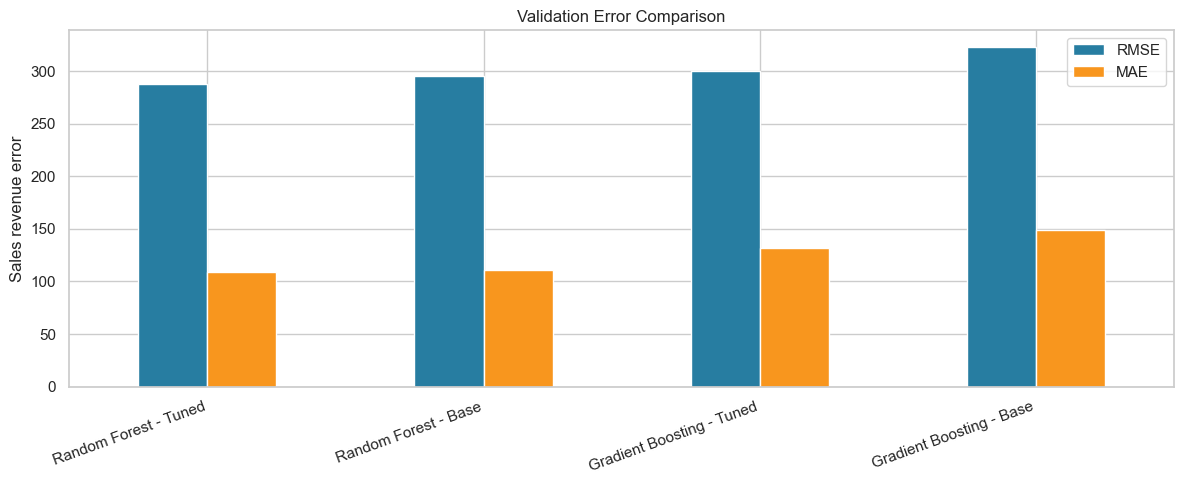

Selected model: Random Forest - Tuned
Selection rule: lowest validation RMSE; the test set was not used for selection.


In [15]:
comparison = pd.DataFrame(validation_results).T.sort_values("RMSE")
display(comparison.style.highlight_min(subset=["RMSE", "MAE"], color="#b7e4c7").highlight_max(subset=["R-squared"], color="#b7e4c7"))

comparison[["RMSE", "MAE"]].plot(kind="bar", figsize=(12, 5), color=["#277da1", "#f8961e"])
plt.title("Validation Error Comparison")
plt.ylabel("Sales revenue error")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

best_model_name = comparison.index[0]
best_model = fitted_models[best_model_name]
print(f"Selected model: {best_model_name}")
print("Selection rule: lowest validation RMSE; the test set was not used for selection.")

,RMSE,MAE,R-squared,MAPE
Random Forest - Tuned,267.4959,104.8857,0.9343,0.0362


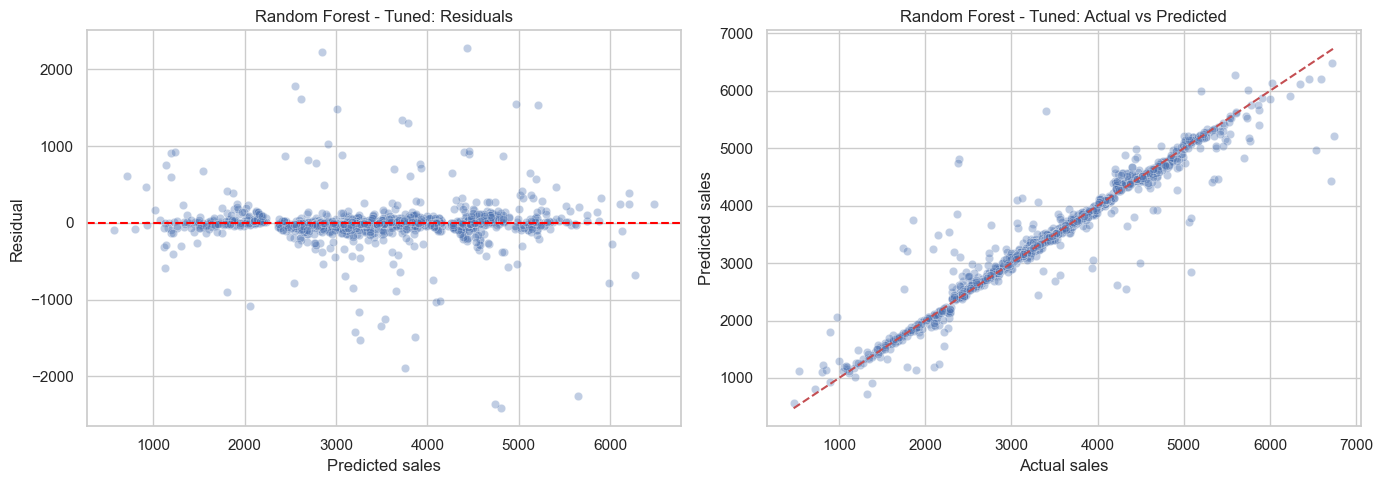

Median absolute error: 32.21
90th-percentile absolute error: 218.66


In [16]:
test_metrics = regression_metrics(best_model, X_test, y_test)
display(pd.DataFrame(test_metrics, index=[best_model_name]))
residual_plots(best_model, X_test, y_test, best_model_name)

test_predictions = best_model.predict(X_test)
absolute_errors = np.abs(y_test.to_numpy() - test_predictions)
print(f"Median absolute error: {np.median(absolute_errors):,.2f}")
print(f"90th-percentile absolute error: {np.quantile(absolute_errors, 0.90):,.2f}")

### **Final Model Interpretation**
The tuned Random Forest achieved **267.50 RMSE**, **104.89 MAE**, **0.9343 R-squared**, and **3.62% MAPE** on the untouched test set. Its median absolute error was only **32.21**, although the 90th-percentile error reached **218.66**, showing that a minority of forecasts remain materially harder. This is the best estimate for new rows from the same four-store environment; performance should not be assumed to transfer unchanged to new outlets or future economic regimes.

,Feature,Importance
2,Product_MRP,0.3701
0,Product_Weight,0.1087
9,Store_Size_Small,0.1021
14,Store_Type_Food Mart,0.0915
12,Store_Location_City_Type_Tier 3,0.0850
11,Store_Location_City_Type_Tier 2,0.0537
13,Store_Type_Departmental Store,0.0495
10,Store_Location_City_Type_Tier 1,0.0495
3,Store_Age_Years,0.0290
16,Store_Type_Supermarket Type2,0.0251


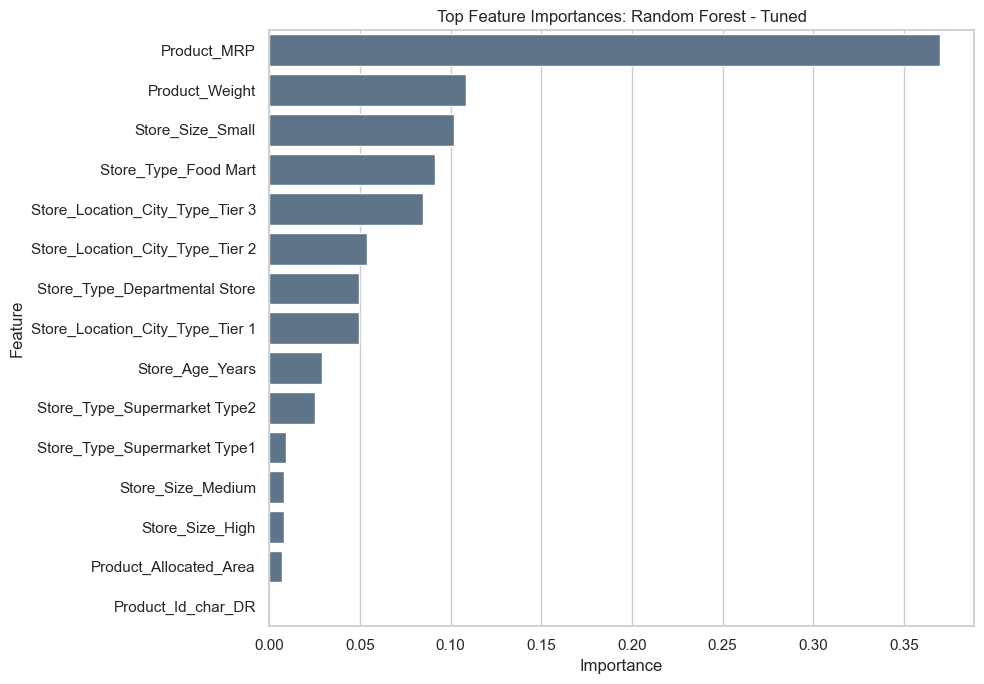

In [17]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["regressor"].feature_importances_
importance_frame = pd.DataFrame({"Feature": feature_names, "Importance": importances}).sort_values("Importance", ascending=False)
display(importance_frame.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_frame.head(15), y="Feature", x="Importance", color="#577590")
plt.title(f"Top Feature Importances: {best_model_name}")
plt.tight_layout()
plt.show()

# **Serialization and Reload Verification**

In [18]:
# Refit the chosen configuration on train + validation after final model selection.
X_development = pd.concat([X_train, X_validation], axis=0)
y_development = pd.concat([y_train, y_validation], axis=0)
deployment_model = clone(best_model).fit(X_development, y_development)

MODEL_PATH = Path("backend/models/superkart_model.joblib")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(deployment_model, MODEL_PATH)
reloaded_model = joblib.load(MODEL_PATH)

original_predictions = deployment_model.predict(X_test)
reloaded_predictions = reloaded_model.predict(X_test)
assert np.allclose(original_predictions, reloaded_predictions)
print(f"Serialized model: {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1_000_000:.2f} MB)")
print("Reloaded predictions exactly match the in-memory pipeline.")
display(pd.DataFrame({"Actual": y_test.iloc[:10], "Reloaded Prediction": reloaded_predictions[:10]}))

Serialized model: backend/models/superkart_model.joblib (53.41 MB)
Reloaded predictions exactly match the in-memory pipeline.


,Actual,Reloaded Prediction
2239,"5,037.8400","5,064.4396"
1328,"2,263.3100","1,884.5788"
5527,"2,467.0900","2,449.8739"
1160,"3,209.7000","3,213.2493"
1822,"1,280.9900","1,393.3464"
4059,"5,165.5200","5,139.3601"
1745,"4,201.1500","4,346.2590"
2658,"6,027.0700","6,042.4963"
4247,"6,529.7400","5,305.0698"
8618,"2,433.8000","2,664.6821"


# **Deployment - Flask Backend**
The backend loads the trusted serialized pipeline once, validates the exact ten-feature schema, exposes health/readiness endpoints, and supports JSON single inference plus multipart CSV batch inference. Input limits and controlled 4xx errors prevent malformed requests from producing server errors.

In [19]:
print(Path("backend/app.py").read_text())

import io
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from flask import Flask, jsonify, request


FEATURES = [
    "Product_Weight",
    "Product_Sugar_Content",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Size",
    "Store_Location_City_Type",
    "Store_Type",
    "Product_Id_char",
    "Store_Age_Years",
    "Product_Type_Category",
]
NUMERIC_FEATURES = [
    "Product_Weight",
    "Product_Allocated_Area",
    "Product_MRP",
    "Store_Age_Years",
]
ALLOWED_CATEGORIES = {
    "Product_Sugar_Content": {"Low Sugar", "Regular", "No Sugar"},
    "Store_Size": {"Small", "Medium", "High"},
    "Store_Location_City_Type": {"Tier 1", "Tier 2", "Tier 3"},
    "Store_Type": {
        "Departmental Store",
        "Food Mart",
        "Supermarket Type1",
        "Supermarket Type2",
        "Supermarket Type3",
    },
    "Product_Id_char": {"FD", "DR", "NC"},
    "Product_Type_Category": {"Perishables", "Non Perishables"},
}
UNSEEN

## **Backend Dependencies and Dockerfile**

In [20]:
print("backend/requirements.txt\n" + Path("backend/requirements.txt").read_text())
print("backend/Dockerfile\n" + Path("backend/Dockerfile").read_text())

backend/requirements.txt
Flask==3.1.2
gunicorn==23.0.0
joblib==1.4.2
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1

backend/Dockerfile
FROM python:3.11.11-slim

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1 \
    MODEL_PATH=/app/models/superkart_model.joblib

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt \
    && useradd --create-home --uid 10001 appuser

COPY app.py .
COPY models ./models
RUN chown -R appuser:appuser /app
USER appuser

EXPOSE 7860
CMD ["gunicorn", "--bind", "0.0.0.0:7860", "--workers", "2", "--threads", "2", "--timeout", "60", "app:superkart_api"]



# **Deployment - Streamlit Frontend**
The frontend provides separate single and batch workflows, communicates with the backend through `BACKEND_URL`, previews uploads, displays predictions and validation errors, and allows forecast downloads.

In [21]:
print(Path("frontend/app.py").read_text())

import io
import os

import pandas as pd
import requests
import streamlit as st


BACKEND_URL = os.getenv("BACKEND_URL", "http://localhost:7860").rstrip("/")
REQUEST_TIMEOUT = int(os.getenv("REQUEST_TIMEOUT_SECONDS", "30"))

st.set_page_config(page_title="SuperKart Sales Forecast", page_icon="SK", layout="wide")
st.title("SuperKart Sales Forecast")
st.caption("Estimate product-store sales for inventory and regional planning.")


def show_api_error(response):
    try:
        details = response.json()
    except ValueError:
        details = response.text
    st.error(f"Prediction failed ({response.status_code}): {details}")


single_tab, batch_tab = st.tabs(["Single prediction", "Batch prediction"])

with single_tab:
    with st.form("single_prediction"):
        left, right = st.columns(2)
        with left:
            product_weight = st.number_input("Product weight", min_value=0.01, value=12.66)
            sugar = st.selectbox("Sugar content", ["Low Sugar", "Regular", "No Sugar"])

## **Frontend Dependencies, Dockerfile, and Service Network**

In [22]:
print("frontend/requirements.txt\n" + Path("frontend/requirements.txt").read_text())
print("frontend/Dockerfile\n" + Path("frontend/Dockerfile").read_text())
print("compose.yaml\n" + Path("compose.yaml").read_text())

frontend/requirements.txt
pandas==2.2.2
numpy==2.0.2
requests==2.32.4
streamlit==1.49.1

frontend/Dockerfile
FROM python:3.11.11-slim

ENV PYTHONDONTWRITEBYTECODE=1 \
    PYTHONUNBUFFERED=1 \
    BACKEND_URL=http://backend:7860

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt \
    && useradd --create-home --uid 10001 appuser

COPY app.py .
RUN chown -R appuser:appuser /app
USER appuser

EXPOSE 8501
HEALTHCHECK --interval=30s --timeout=5s --start-period=10s --retries=3 \
    CMD python -c "import urllib.request; urllib.request.urlopen('http://localhost:8501/_stcore/health')"
CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0", "--server.port=8501", "--server.headless=true"]

compose.yaml
services:
  backend:
    build: ./backend
    environment:
      MODEL_PATH: /app/models/superkart_model.joblib
      MAX_BATCH_ROWS: 10000
      MAX_UPLOAD_BYTES: 5242880
    ports:
      - "7860:7860"
    healthcheck:
      test: ["CMD", "python", "-c

# **Inference Verification**

In [23]:
# Import the Flask app after serialization so it can load the generated artifact.
import importlib.util

spec = importlib.util.spec_from_file_location("superkart_backend", Path("backend/app.py"))
backend_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(backend_module)
api_client = backend_module.superkart_api.test_client()

single_payload = {
    "Product_Weight": 12.66,
    "Product_Sugar_Content": "Low Sugar",
    "Product_Allocated_Area": 0.027,
    "Product_MRP": 117.08,
    "Store_Size": "Medium",
    "Store_Location_City_Type": "Tier 2",
    "Store_Type": "Supermarket Type2",
    "Product_Id_char": "FD",
    "Store_Age_Years": 16,
    "Product_Type_Category": "Perishables",
}
single_response = api_client.post("/v1/predict", json=single_payload)
print("Single inference status:", single_response.status_code)
print(json.dumps(single_response.get_json(), indent=2))
assert single_response.status_code == 200

Single inference status: 200
{
  "prediction": 2884.28,
  "warnings": []
}


In [24]:
batch_dataset = pd.read_csv(BATCH_PATH)
batch_bytes = batch_dataset.to_csv(index=False).encode("utf-8")
batch_response = api_client.post(
    "/v1/predictbatch",
    data={"file": (io.BytesIO(batch_bytes), "Batch_Data_SuperKart.csv")},
    content_type="multipart/form-data",
)
print("Batch inference status:", batch_response.status_code)
batch_body = batch_response.get_json()
print(json.dumps(batch_body, indent=2))
assert batch_response.status_code == 200
batch_predictions = batch_body.get("predictions", batch_body)
batch_output = batch_dataset.copy()
batch_output["Predicted_Sales"] = [batch_predictions[str(index)] for index in batch_output.index]
display(batch_output)

Batch inference status: 200
{
  "predictions": {
    "0": 3957.01,
    "1": 2914.59,
    "2": 4090.58,
    "3": 1897.81,
    "4": 4035.71,
    "5": 4948.55,
    "6": 2501.61,
    "7": 2363.69,
    "8": 5024.97,
    "9": 2212.95
  },
  "warnings": [
    "Product_Weight contains values outside the training range [4.0, 22.0]",
    "Store_Age_Years contains values outside the training range [16.0, 38.0]",
    "Store_Type contains categories unseen during training: ['Supermarket Type3']"
  ]
}


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Id_char,Store_Age_Years,Product_Type_Category,Predicted_Sales
0,12.6600,Low Sugar,0.0270,117.0800,Small,Tier 1,Supermarket Type1,FD,16,Perishables,"3,957.0100"
1,8.2000,Regular,0.0450,85.5000,Medium,Tier 2,Supermarket Type2,DR,22,Non Perishables,"2,914.5900"
2,15.4000,No Sugar,0.0120,210.7500,High,Tier 3,Departmental Store,NC,8,Non Perishables,"4,090.5800"
3,5.7500,Regular,0.0600,55.2000,Small,Tier 1,Food Mart,FD,30,Perishables,"1,897.8100"
4,19.3000,Low Sugar,0.0330,145.6000,Medium,Tier 2,Supermarket Type3,DR,12,Non Perishables,"4,035.7100"
5,10.0000,No Sugar,0.0500,92.4000,High,Tier 1,Supermarket Type1,NC,5,Non Perishables,"4,948.5500"
6,7.8500,Regular,0.0180,178.9000,Small,Tier 3,Supermarket Type2,FD,19,Perishables,"2,501.6100"
7,14.1000,Low Sugar,0.0410,63.2500,Medium,Tier 2,Food Mart,DR,27,Perishables,"2,363.6900"
8,3.5000,No Sugar,0.0090,250.0000,High,Tier 1,Departmental Store,NC,10,Non Perishables,"5,024.9700"
9,11.2500,Regular,0.0550,130.4500,Small,Tier 3,Supermarket Type3,FD,14,Perishables,"2,212.9500"


## **GitHub and Codespaces Deployment**
The backend and frontend files are version-controlled in the public repository below. GitHub Codespaces builds both containers through `compose.yaml`. Port 7860 exposes the Flask API and port 8501 exposes Streamlit. These session-dependent URLs remain available while the Codespace is running.

- Repository: `https://github.com/andvalsol/superkart-sales-forecast`
- Codespace: `superkart-deployment-w9jwq44vpp72g6gp`
- Public API: `https://superkart-deployment-w9jwq44vpp72g6gp-7860.app.github.dev`
- Public Streamlit UI: `https://superkart-deployment-w9jwq44vpp72g6gp-8501.app.github.dev`
- Backend path: `/v1/predict` and `/v1/predictbatch`
- Frontend port: `8501`
- Backend port: `7860`
- External verification: readiness returned HTTP 200, single inference returned `2884.28`, batch inference returned 10 predictions, and both Streamlit workflows rendered successfully.

# **Actionable Insights and Business Recommendations**

## **Insights**
- Product MRP and weight are the strongest numeric sales signals. Higher-priced and heavier products generally produce greater product-store revenue.
- Store context is critical: Departmental Store/Tier 1 observations substantially outperform Food Mart/Tier 3 observations in this sample. These attributes are confounded and describe only four stores, so they are predictive rather than causal.
- Display allocation shows little association with revenue. SuperKart should not assume that increasing shelf area alone will increase sales without a controlled experiment.
- Product type and sugar content have much smaller marginal sales differences than price, weight, and store configuration.

## **Recommendations**
- Use forecasts to rank product-store combinations for replenishment and regional planning, while retaining planner review for unusually high forecasts or out-of-range inputs.
- Prioritize price-positioning and assortment decisions by store format and city tier; do not apply one inventory rule uniformly across all outlets.
- Evaluate display-area changes through randomized or phased store experiments before using allocation as a sales lever.
- Add date, units sold, promotions, stock-outs, holidays, competitor pricing, and local economic indicators. These are required for a genuine upcoming-quarter time-series forecast and more reliable causal decisions.
- Validate on newly opened stores before network expansion. Current random splits measure interpolation among four known stores and may overstate performance on unseen outlets.
- Monitor RMSE, MAE, residual bias, input drift, and error by store type/city tier. Retrain through a governed process when drift or forecast error breaches agreed thresholds.
- Keep human oversight, model/version logs, schema validation, access controls, and a rollback artifact in production.

# **Conclusion**
The project delivers a reproducible end-to-end forecasting workflow rather than only a fitted estimator. The tuned Random Forest explains **93.43%** of held-out sales variation with RMSE of **267.50**. The final artifact contains preprocessing and regression in one pipeline; serialization reload checks matched exactly, and local API verification returned HTTP 200 for single and 10-row batch inference. Deployment should begin as a monitored planning aid while SuperKart expands temporal and store coverage.